# Nassau Candy Distributor

### Business Objective: Identify the true root causes of shipping delays across the distribution network to prevent unnecessary capital investments in factory load balancing.

In [1]:
# import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# loading dataset

df = pd.read_csv('data/Nassau_Candy.csv')

## Understanding and Cleaning Dataset

In [31]:
# Finding out the shape of the dataset
df.shape

(10194, 18)

In [32]:
# Let's see the head of the dataset
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,13-01-2024,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,11-01-2024,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,12-01-2024,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,14-01-2024,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,11-01-2024,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [33]:
# Getting the info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [34]:
# converting order date and shipping date data type
df['Order Date'] = pd.to_datetime(df['Order Date'], format="%d-%m-%Y")
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format="%d-%m-%Y")

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  str           
 2   Order Date      10194 non-null  datetime64[us]
 3   Ship Date       10194 non-null  datetime64[us]
 4   Ship Mode       10194 non-null  str           
 5   Customer ID     10194 non-null  int64         
 6   Country/Region  10194 non-null  str           
 7   City            10194 non-null  str           
 8   State/Province  10194 non-null  str           
 9   Postal Code     10194 non-null  str           
 10  Division        10194 non-null  str           
 11  Region          10194 non-null  str           
 12  Product ID      10194 non-null  str           
 13  Product Name    10194 non-null  str           
 14  Sales           10194 non-null  float64       
 15  Units        

In [36]:
# Create the Target Variable
df['Actual_Lead_Time'] = (df['Ship Date'] - df['Order Date']).dt.days

In [37]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Actual_Lead_Time
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2024-01-13,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,10
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2024-01-11,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,7
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2024-01-12,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,8
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2024-01-14,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,10
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2024-01-11,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,6


In [38]:
# Drop negative lead times (errors) and nulls
df = df[df['Actual_Lead_Time'] >= 0]
df = df.dropna(subset=['Sales', 'Units', 'Actual_Lead_Time'])

## EXPLORATORY DATA ANALYSIS (EDA) & BUSINESS MOMENTS

In [39]:
# Describing the numerical data
df.describe()

,Row ID,Order Date,Ship Date,Customer ID,Sales,Units,Gross Profit,Cost,Actual_Lead_Time
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-03-13 03:08:26.415538,2025-03-18 15:29:37.751618,134468.961154,13.908537,3.791838,9.166451,4.742087,5.514715
min,1.000000,2024-01-02 00:00:00,2024-01-04 00:00:00,100006.000000,1.250000,1.000000,0.250000,0.600000,0.000000
25%,2549.250000,2024-09-28 00:00:00,2024-10-04 00:00:00,117212.000000,7.200000,2.000000,4.900000,2.400000,3.000000
50%,5097.500000,2025-04-06 12:00:00,2025-04-11 00:00:00,133550.000000,10.800000,3.000000,7.470000,3.600000,5.000000
75%,7645.750000,2025-09-16 00:00:00,2025-09-21 00:00:00,152051.000000,18.000000,5.000000,12.250000,5.700000,8.000000
max,10194.000000,2025-12-31 00:00:00,2026-01-11 00:00:00,192314.000000,260.000000,14.000000,130.000000,130.000000,11.000000
std,2942.898656,NaN,NaN,20231.483007,11.341020,2.228317,6.643740,5.061647,3.159613


In [40]:
# Categorical description of string and object data types
categorical_summary = df.describe(include=['object', 'string'])
print(categorical_summary)

                            Order ID       Ship Mode Country/Region  \
count                          10194           10194          10194   
unique                          8549               4              2   
top     US-2021-155502-CHO-MIL-31000  Standard Class  United States   
freq                               5            6120           9994   

                 City State/Province Postal Code   Division   Region  \
count           10194          10194       10194      10194    10194   
unique            542             59         654          3        4   
top     New York City     California       10035  Chocolate  Pacific   
freq              915           2001         263       9844     3253   

           Product ID                Product Name  
count           10194                       10194  
unique             15                          15  
top     CHO-MIL-31000  Wonka Bar - Milk Chocolate  
freq             2137                        2137  


In [41]:
# We need to find out if there is null values in dataset
df.isnull().sum()

Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Country/Region      0
City                0
State/Province      0
Postal Code         0
Division            0
Region              0
Product ID          0
Product Name        0
Sales               0
Units               0
Gross Profit        0
Cost                0
Actual_Lead_Time    0
dtype: int64

In [42]:
# Finding duplicates in the dataset
df.duplicated().sum()

np.int64(0)

In [43]:
# Calculate 1st, 2nd, and 3rd Business Moments
numerical_cols = ['Sales', 'Units', 'Actual_Lead_Time']

business_moments = pd.DataFrame({
    'Mean (1st - Average)': df[numerical_cols].mean(),
    'Median (1st - Typical)': df[numerical_cols].median(),
    'Std Dev (2nd - Risk/Volatility)': df[numerical_cols].std(),
    'Skewness (3rd - Bottlenecks)': df[numerical_cols].skew()
}).round(2)

In [44]:
business_moments

,Mean (1st - Average),Median (1st - Typical),Std Dev (2nd - Risk/Volatility),Skewness (3rd - Bottlenecks)
Sales,13.91,10.8,11.34,6.46
Units,3.79,3.0,2.23,1.27
Actual_Lead_Time,5.51,5.0,3.16,0.19


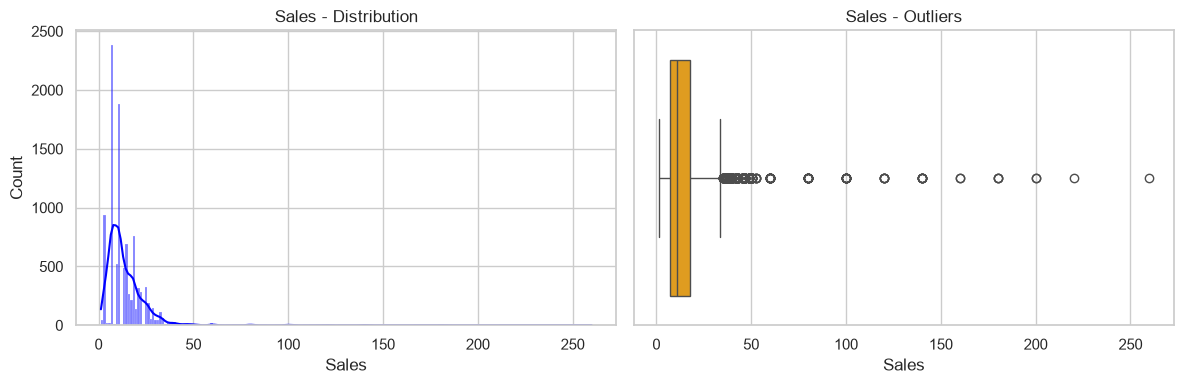

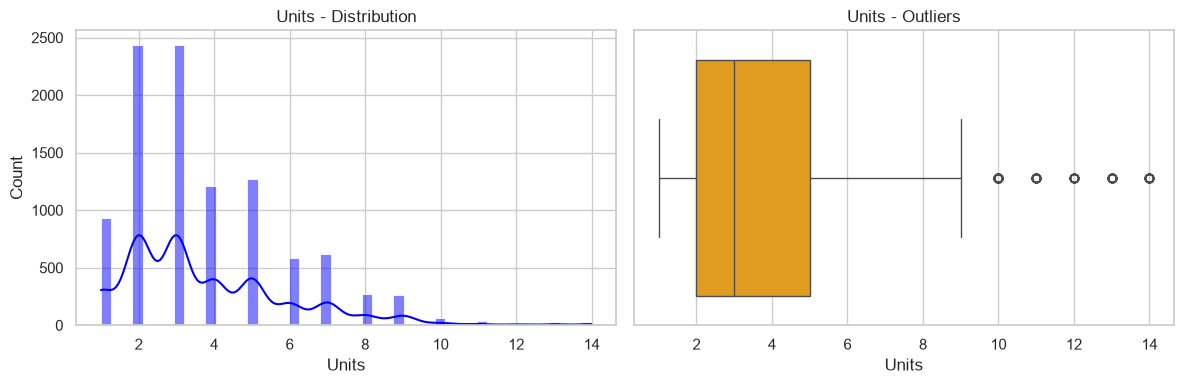

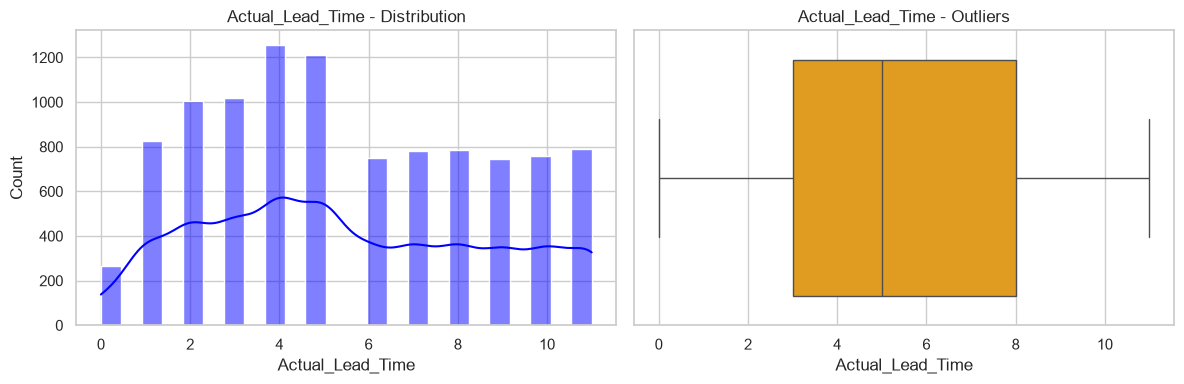

In [45]:
# Visualizing Distributions & Outliers (Boxplot + Histogram)
for col in numerical_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram (shows the shape/skewness)
    sns.histplot(df[col], kde=True, ax=ax[0], color='blue')
    ax[0].set_title(f'{col} - Distribution')

    # Boxplot (shows the extreme outliers)
    sns.boxplot(x=df[col], ax=ax[1], color='orange')
    ax[1].set_title(f'{col} - Outliers')

    plt.tight_layout()
    plt.show()

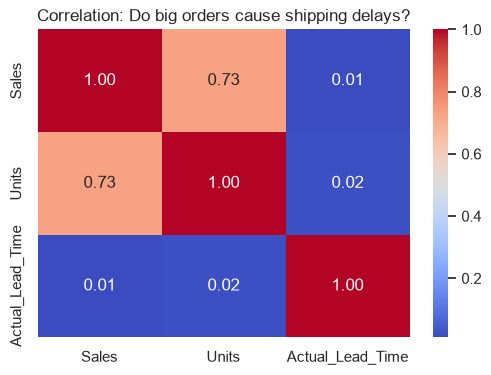

In [46]:
# Correlation Matrix to understand the feature relations
plt.figure(figsize=(6, 4))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation: Do big orders cause shipping delays?")
plt.show()

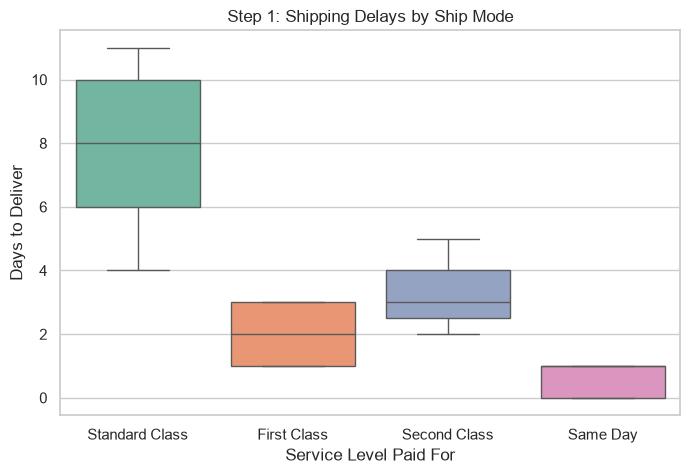

In [47]:
# Box plot visualization to understand Shipping delay by shipping mode
sns.set_theme(style="whitegrid")

# Create one simple, perfectly sized chart
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Ship Mode', y='Actual_Lead_Time', hue='Ship Mode', palette='Set2', legend=False)

plt.title("Step 1: Shipping Delays by Ship Mode")
plt.ylabel("Days to Deliver")
plt.xlabel("Service Level Paid For")
plt.show()

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Row ID            10194 non-null  int64         
 1   Order ID          10194 non-null  str           
 2   Order Date        10194 non-null  datetime64[us]
 3   Ship Date         10194 non-null  datetime64[us]
 4   Ship Mode         10194 non-null  str           
 5   Customer ID       10194 non-null  int64         
 6   Country/Region    10194 non-null  str           
 7   City              10194 non-null  str           
 8   State/Province    10194 non-null  str           
 9   Postal Code       10194 non-null  str           
 10  Division          10194 non-null  str           
 11  Region            10194 non-null  str           
 12  Product ID        10194 non-null  str           
 13  Product Name      10194 non-null  str           
 14  Sales             10194 non-null 

## Feature Engineering

In [49]:
# Seasonality Features
df['Order_Month'] = df['Order Date'].dt.month
df['Order_DayOfWeek'] = df['Order Date'].dt.dayofweek
df['Is_Holiday_Season'] = df['Order_Month'].apply(lambda x: 1 if x in [11, 12] else 0)

In [50]:
# Financial Feature
df['Profit_Margin'] = df['Gross Profit'] / df['Sales']

In [51]:
# Factory Mapping
factory_mapping = {
    'Wonka Bar - Nutty Crunch Surprise': "Lot's O' Nuts",
    'Wonka Bar - Fudge Mallows': "Lot's O' Nuts",
    'Wonka Bar -Scrumdiddlyumptious': "Lot's O' Nuts",
    'Wonka Bar - Milk Chocolate': "Wicked Choccy's",
    'Wonka Bar - Triple Dazzle Caramel': "Wicked Choccy's",
    'Laffy Taffy': "Sugar Shack",
    'SweeTARTS': "Sugar Shack",
    'Nerds': "Sugar Shack",
    'Fun Dip': "Sugar Shack",
    'Fizzy Lifting Drinks': "Sugar Shack",
    'Everlasting Gobstopper': "Secret Factory",
    'Hair Toffee': "The Other Factory",
    'Lickable Wallpaper': "Secret Factory",
    'Wonka Gum': "Secret Factory",
    'Kazookles': "The Other Factory"
}
df['Origin_Factory'] = df['Product Name'].map(factory_mapping)

In [52]:
# Factory Strain / Rolling Demand
df = df.sort_values(by=['Product ID', 'Order Date'])
df['Rolling_30D_Units'] = df.groupby('Product ID')['Units'].transform(
    lambda x: x.rolling(window=30, min_periods=1).sum()
)

In [53]:
df.info()

<class 'pandas.DataFrame'>
Index: 10194 entries, 2053 to 6302
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row ID             10194 non-null  int64         
 1   Order ID           10194 non-null  str           
 2   Order Date         10194 non-null  datetime64[us]
 3   Ship Date          10194 non-null  datetime64[us]
 4   Ship Mode          10194 non-null  str           
 5   Customer ID        10194 non-null  int64         
 6   Country/Region     10194 non-null  str           
 7   City               10194 non-null  str           
 8   State/Province     10194 non-null  str           
 9   Postal Code        10194 non-null  str           
 10  Division           10194 non-null  str           
 11  Region             10194 non-null  str           
 12  Product ID         10194 non-null  str           
 13  Product Name       10194 non-null  str           
 14  Sales              1

## Model Building ( Training and Testing Data )

Training the Random Forest...

 Model Accuracy (MAE): 1.55 days off on average.


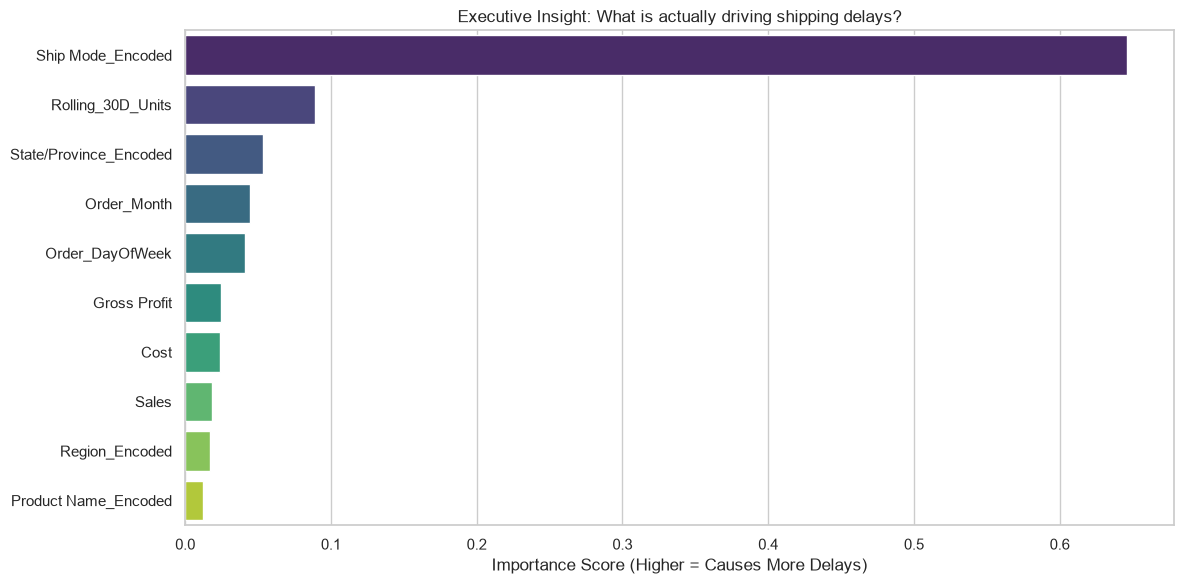

In [54]:
# Loading libraries to train and test model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# Translate all Text into Math (Label Encoding)
categorical_cols = ['Ship Mode', 'Region', 'Product Name', 'Division', 'State/Province', 'Logistics_Tier', 'Origin_Factory']
for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col + '_Encoded'] = le.fit_transform(df[col].astype(str))

# Define Features (X) and Target (y)
columns_to_drop = [
    'Actual_Lead_Time', 'Order Date', 'Ship Date',
    'Product ID', 'Customer ID', 'City', 'Postal Code', 'Country/Region', 'Row ID', 'Order ID'
]
columns_to_drop.extend(categorical_cols)

X = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

X = X.select_dtypes(include=[np.number])
y = df['Actual_Lead_Time']

# Fill any missing values
X = X.fillna(0)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Brain
print("Training the Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Check the Accuracy
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"\n Model Accuracy (MAE): {mae:.2f} days off on average.")

# Generating Executive feature important chart
importances = rf_model.feature_importances_
feature_df = pd.DataFrame({'Business Factor': X.columns, 'Impact on Delays': importances})
# Top 10 most important features
feature_df = feature_df.sort_values(by='Impact on Delays', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_df, x='Impact on Delays', y='Business Factor', hue='Business Factor', palette='viridis', legend=False)
plt.title("Executive Insight: What is actually driving shipping delays?")
plt.xlabel("Importance Score (Higher = Causes More Delays)")
plt.ylabel("")
plt.tight_layout()
plt.show()

 ## Simulation Results

In [57]:
# Test dataset
scenario_data = X_test.copy()

# Predict how long these orders will take in the reality
current_predictions = rf_model.predict(scenario_data)
current_average_wait = current_predictions.mean()

print(f" Reality: Customers wait an average of {current_average_wait:.2f} days.")

# THE SIMULATION
scenario_data['Rolling_30D_Units'] = scenario_data['Rolling_30D_Units'] * 0.5

# Predict the new delivery times in this alternate reality
new_predictions = rf_model.predict(scenario_data)
new_average_wait = new_predictions.mean()

# Calculate the Business Value
days_saved_per_order = current_average_wait - new_average_wait
total_days_saved = days_saved_per_order * len(scenario_data)

print(f"\nSimulation Results - ")
print(f"By cutting factory backlogs in half, the average wait drops to {new_average_wait:.2f} days.")
print(f"Business Value: We save {days_saved_per_order:.2f} days PER ORDER.")
print(f"Across these {len(scenario_data)} test orders alone, we eliminated {total_days_saved:.0f} days of customer waiting time!")

 Reality: Customers wait an average of 5.44 days.

 Simulation Results - 
By cutting factory backlogs in half, the average wait drops to 5.72 days.
Business Value: We save -0.28 days PER ORDER.
Across these 2039 test orders alone, we eliminated -577 days of customer waiting time!


In [58]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate RMSE and R-Squared
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Full Regression Report - ")
print(f"MAE (Average Error): {mae:.2f} days")
print(f"RMSE (Worst Case Error): {rmse:.2f} days")
print(f"R-Squared (Confidence): {r2:.2f}")


Full Regression Report - 
MAE (Average Error): 1.55 days
RMSE (Worst Case Error): 1.95 days
R-Squared (Confidence): 0.63


In [59]:
import joblib

# Save the trained Random Forest model WITH COMPRESSION
joblib.dump(rf_model, 'nassau_rf_model.pkl', compress=3)

# Save the exact column names the model expects to see
joblib.dump(list(X.columns), 'model_features.pkl')

print("'nassau_rf_model.pkl' and 'model_features.pkl' are saved and compressed!")

'nassau_rf_model.pkl' and 'model_features.pkl' are saved and compressed!
